In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = r"D:\AI-Fraud-Investigation-Assistant\data\raw\creditcard.csv"
df = pd.read_csv(DATA_PATH)

In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
df.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
#creating a directory to store images
import os
os.makedirs("images", exist_ok=True)

In [8]:
print("\nClass distribution:\n", df['Class'].value_counts())


Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


Understanding the Imbalanced data

In [9]:
legit_count = df[df['Class'] == 0].shape[0]
fraud_count = df[df['Class'] == 1].shape[0]
fraud_pct = round(df['Class'].mean()*100,4)

print(f"\nLegit transactions : {legit_count}  ({round(100 - fraud_pct, 2)}%)")
print(f"Fraud transactions : {fraud_count}  ({fraud_pct}%)")
print(f"\nImbalance ratio    : {round(legit_count / fraud_count, 1)}:1  (legit:fraud)")


Legit transactions : 284315  (99.83%)
Fraud transactions : 492  (0.1727%)

Imbalance ratio    : 577.9:1  (legit:fraud)


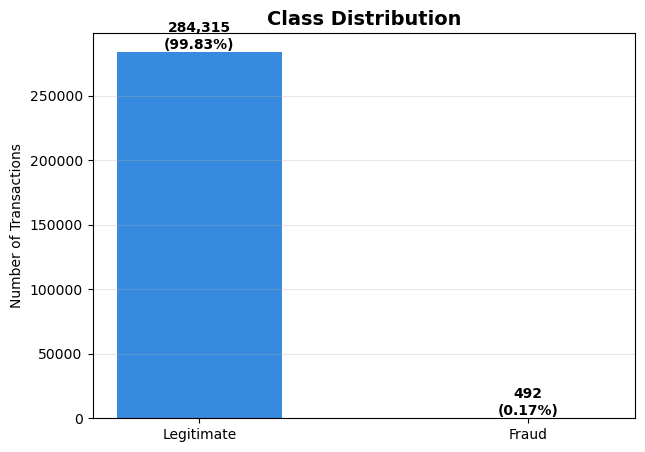

In [10]:
import matplotlib.pyplot as plt

counts = [legit_count, fraud_count]
labels = ['Legitimate', 'Fraud']
colors = ['#378ADD', '#E24B4A']

plt.figure(figsize=(7,5))

bars = plt.bar(labels, counts, color=colors, width=0.5)

plt.title("Class Distribution", fontsize=14, fontweight='bold')
plt.ylabel("Number of Transactions")

total = sum(counts)

for bar, value in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f'{value:,}\n({100*value/total:.2f}%)',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.grid(axis='y', alpha=0.3)

plt.savefig(
    "images/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Exploring Amount & Time Features

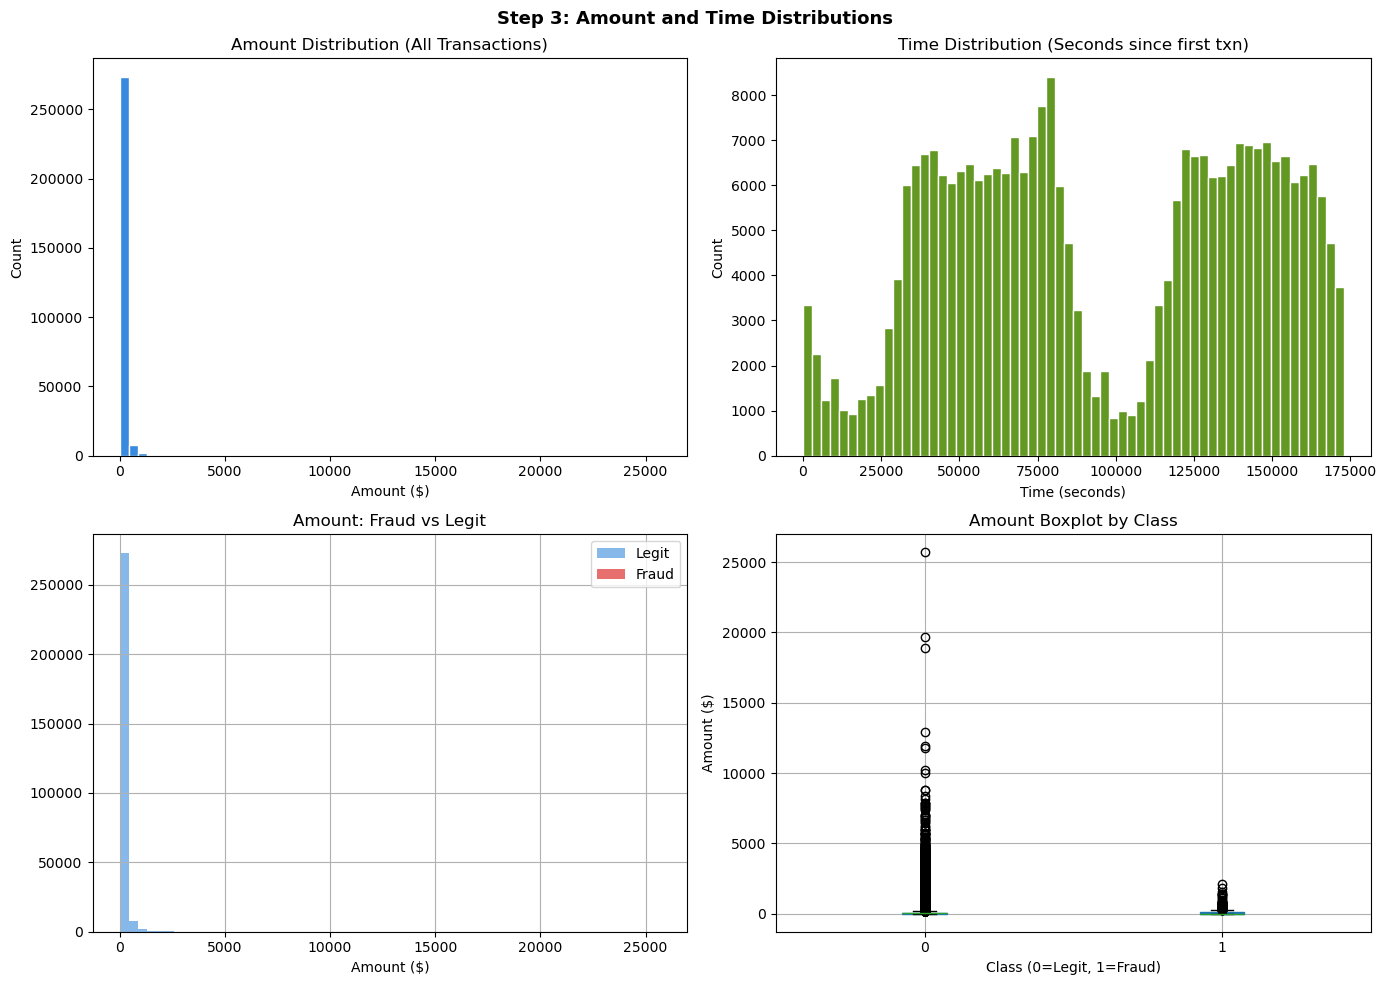

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
# Amount distribution — all
axes[0][0].hist(df['Amount'], bins=60, color='#378ADD', edgecolor='white')
axes[0][0].set_title('Amount Distribution (All Transactions)')
axes[0][0].set_xlabel('Amount ($)')
axes[0][0].set_ylabel('Count')
 
# Time distribution — all
axes[0][1].hist(df['Time'], bins=60, color='#639922', edgecolor='white')
axes[0][1].set_title('Time Distribution (Seconds since first txn)')
axes[0][1].set_xlabel('Time (seconds)')
axes[0][1].set_ylabel('Count')
 
# Amount — Fraud vs Legit comparison
df[df['Class'] == 0]['Amount'].hist(bins=60, ax=axes[1][0],
                                    color='#378ADD', alpha=0.6, label='Legit')
df[df['Class'] == 1]['Amount'].hist(bins=60, ax=axes[1][0],
                                    color='#E24B4A', alpha=0.8, label='Fraud')
axes[1][0].set_title('Amount: Fraud vs Legit')
axes[1][0].set_xlabel('Amount ($)')
axes[1][0].legend()
 
# Boxplot of Amount by class
df.boxplot(column='Amount', by='Class', ax=axes[1][1],
           patch_artist=True)
axes[1][1].set_title('Amount Boxplot by Class')
axes[1][1].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[1][1].set_ylabel('Amount ($)')
 
plt.suptitle('Step 3: Amount and Time Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig(
    "images/distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Correlation Heatmap


Top 10 features Positively correlated with fraud:
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Name: Class, dtype: float64

Top 10 features Negatively correlated with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64


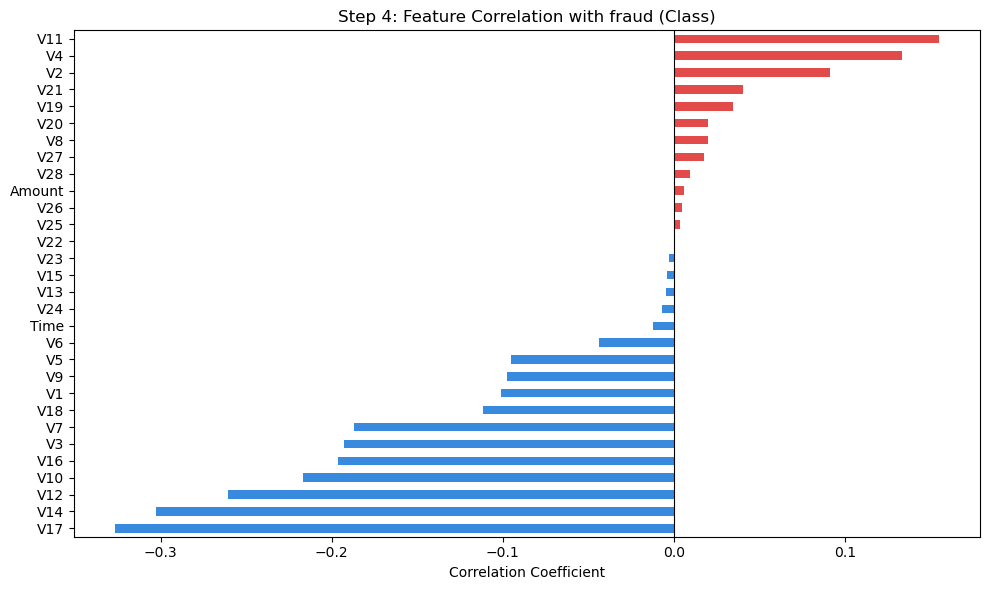

In [12]:
correlations = df.corr()['Class'].drop('Class').sort_values()

print("\nTop 10 features Positively correlated with fraud:")
print(correlations.tail(10))
print("\nTop 10 features Negatively correlated with fraud:")
print(correlations.head(10))

plt.figure(figsize=(10,6))
colors = ['#E24B4A' if c > 0 else '#378ADD' for c in correlations]
correlations.plot(kind='barh', color=colors)
plt.title('Step 4: Feature Correlation with fraud (Class)')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black',linewidth=0.8)
plt.tight_layout()

plt.savefig(
    "images/feature_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Scale Amount and Time

In [13]:
from sklearn.preprocessing import StandardScaler

# Create one scaler for both numerical features
scaler = StandardScaler()

# Scale Time and Amount together
df[['Time', 'Amount']] = scaler.fit_transform(df[['Time', 'Amount']])

print("\nAfter scaling (StandardScaler):")
print(df[['Time', 'Amount']].describe())


After scaling (StandardScaler):
               Time        Amount
count  2.848070e+05  2.848070e+05
mean  -5.109395e-17 -3.672378e-17
std    1.000002e+00  1.000002e+00
min   -1.996583e+00 -3.532294e-01
25%   -8.552120e-01 -3.308401e-01
50%   -2.131453e-01 -2.652715e-01
75%    9.372174e-01 -4.471707e-02
max    1.642058e+00  1.023622e+02


Train and Split

In [14]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

X = df.drop('Class',axis=1)
y = df['Class']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42, stratify=y)

print(f"\nTrain set : {X_train.shape[0]} rows")
print(f"Test set  : {X_test.shape[0]} rows")
print(f"\nTrain — Fraud: {y_train.sum()} ({round(y_train.mean()*100, 3)}%)")
print(f"Test  — Fraud: {y_test.sum()} ({round(y_test.mean()*100, 3)}%)")


Train set : 227845 rows
Test set  : 56962 rows

Train — Fraud: 394 (0.173%)
Test  — Fraud: 98 (0.172%)


Handling Class Imbalance By (Two Approaches)

In [ ]:
# Approach 1: scale_pos_weight.
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg/pos

print(f"\nApproach A — scale_pos_weight:")
print(f"  Legit count  : {neg}")
print(f"  Fraud count  : {pos}")
print(f"  Weight value : {round(scale_pos_weight, 1)}")
print(f"  Meaning      : XGBoost treats each fraud row as {round(scale_pos_weight)}x important")


Approach A — scale_pos_weight:
  Legit count  : 227451
  Fraud count  : 394
  Weight value : 577.3
  Meaning      : XGBoost treats each fraud row as 577x important


In [16]:
from imblearn.over_sampling import SMOTE
# Approach 2: SMOTE 

smote = SMOTE(random_state=42)
X_train_smote,y_train_smote = smote.fit_resample(X_train,y_train)

print(f"  After SMOTE  — Fraud: {y_train_smote.sum()}, Legit: {(y_train_smote==0).sum()}")
print(f"  New train size: {X_train_smote.shape[0]} rows")

  After SMOTE  — Fraud: 227451, Legit: 227451
  New train size: 454902 rows


Training Dataset Before SMOTE
Total Samples      : 227,845
Legitimate         : 227,451 (99.83%)
Fraud              : 394 (0.17%)
Imbalance Ratio    : 577.3 : 1


Training Dataset After SMOTE
Total Samples      : 454,902
Legitimate         : 227,451 (50.00%)
Fraud              : 227,451 (50.00%)
Imbalance Ratio    : 1.0 : 1


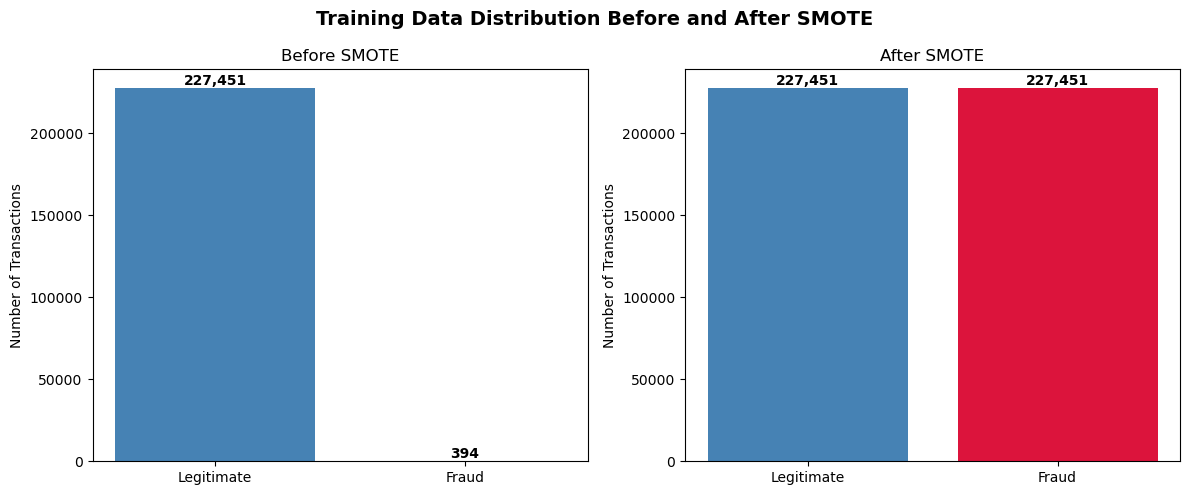

In [17]:
# Visualizing before/after SMOTE
import matplotlib.pyplot as plt

# ================================
# Before SMOTE Statistics
# ================================
before_legit = (y_train == 0).sum()
before_fraud = (y_train == 1).sum()

before_total = len(y_train)

before_legit_pct = before_legit / before_total * 100
before_fraud_pct = before_fraud / before_total * 100

# ================================
# After SMOTE Statistics
# ================================
after_legit = (y_train_smote == 0).sum()
after_fraud = (y_train_smote == 1).sum()

after_total = len(y_train_smote)

after_legit_pct = after_legit / after_total * 100
after_fraud_pct = after_fraud / after_total * 100

# ================================
# Print Summary
# ================================
print("="*60)
print("Training Dataset Before SMOTE")
print("="*60)
print(f"Total Samples      : {before_total:,}")
print(f"Legitimate         : {before_legit:,} ({before_legit_pct:.2f}%)")
print(f"Fraud              : {before_fraud:,} ({before_fraud_pct:.2f}%)")
print(f"Imbalance Ratio    : {before_legit/before_fraud:.1f} : 1")

print("\n")

print("="*60)
print("Training Dataset After SMOTE")
print("="*60)
print(f"Total Samples      : {after_total:,}")
print(f"Legitimate         : {after_legit:,} ({after_legit_pct:.2f}%)")
print(f"Fraud              : {after_fraud:,} ({after_fraud_pct:.2f}%)")
print(f"Imbalance Ratio    : {after_legit/after_fraud:.1f} : 1")

# ================================
# Visualization
# ================================
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Before SMOTE
bars1 = axes[0].bar(
    ['Legitimate', 'Fraud'],
    [before_legit, before_fraud],
    color=['steelblue', 'crimson']
)

axes[0].set_title("Before SMOTE")
axes[0].set_ylabel("Number of Transactions")

for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# After SMOTE
bars2 = axes[1].bar(
    ['Legitimate', 'Fraud'],
    [after_legit, after_fraud],
    color=['steelblue', 'crimson']
)

axes[1].set_title("After SMOTE")
axes[1].set_ylabel("Number of Transactions")

for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.suptitle(
    "Training Data Distribution Before and After SMOTE",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "images/smote_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Training All 4 Models

In [18]:
def evaluate_model(name,model,X_tr,y_tr,X_te,y_te):
    model.fit(X_tr,y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1]


    print(classification_report(y_te,y_pred,target_names=['Legit','Fraud']))

    return {
        'Model': name,
        'Recall': round(recall_score(y_te,y_pred),4),
        'Precision': round(precision_score(y_te,y_pred),4),
        'F1': round(f1_score(y_te,y_pred),4),
        'AUC-ROC': round(roc_auc_score(y_te,y_prob),4),
    },model

result_list = []
trained_models = {}



In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                            roc_auc_score,f1_score,precision_score,
                            recall_score,RocCurveDisplay,PrecisionRecallDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1.Logistic Regression
lr = LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)
res, m = evaluate_model("Logistic Regression",lr,
                       X_train,y_train,X_test,y_test)
result_list.append(res); 
trained_models[res['Model']] = m

              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [20]:
# 2.Random Forest 
rf = RandomForestClassifier(n_estimators=100,class_weight='balanced',
                           random_state=42,n_jobs=-1)

res,m = evaluate_model("Random Forest",rf,
                      X_train,y_train,X_test,y_test)
result_list.append(res); trained_models[res['Model']] = m

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [21]:
# 3.Xgboost with scale_pos_weight
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight,
                  n_estimators=100,random_state=42,
                  eval_metric='logloss')

res,m = evaluate_model("Xgboost scale_pos_weigth",xgb,
                      X_train,y_train,X_test,y_test)
result_list.append(res); trained_models[res['Model']] = m

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [22]:
# 4. Xgboost with SMOTE
xgb_smote = XGBClassifier(n_estimators=100,random_state=42,
                         eval_metric='logloss')
res,m = evaluate_model("xgboost with smote",xgb_smote,
                      X_train,y_train,X_test,y_test)
result_list.append(res); trained_models[res['Model']] = m

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.90      0.80      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [23]:
# 5.Lightgbm 
lgbm = LGBMClassifier(is_unbalance=True, n_estimators=100,
                     random_state=42,verbose=-1)
res,m = evaluate_model("Lightgbm",lgbm,
                      X_train,y_train,X_test,y_test)
result_list.append(res); trained_models[res['Model']] = m

              precision    recall  f1-score   support

       Legit       1.00      0.93      0.96     56864
       Fraud       0.02      0.89      0.04        98

    accuracy                           0.93     56962
   macro avg       0.51      0.91      0.50     56962
weighted avg       1.00      0.93      0.96     56962



                   Model  Recall  Precision     F1  AUC-ROC
Xgboost scale_pos_weigth  0.8265     0.8710 0.8482   0.9726
      xgboost with smote  0.7959     0.8966 0.8432   0.9220
           Random Forest  0.7449     0.9605 0.8391   0.9529
     Logistic Regression  0.9184     0.0609 0.1141   0.9722
                Lightgbm  0.8878     0.0217 0.0424   0.9095
Winner (highest F1): Xgboost scale_pos_weigth


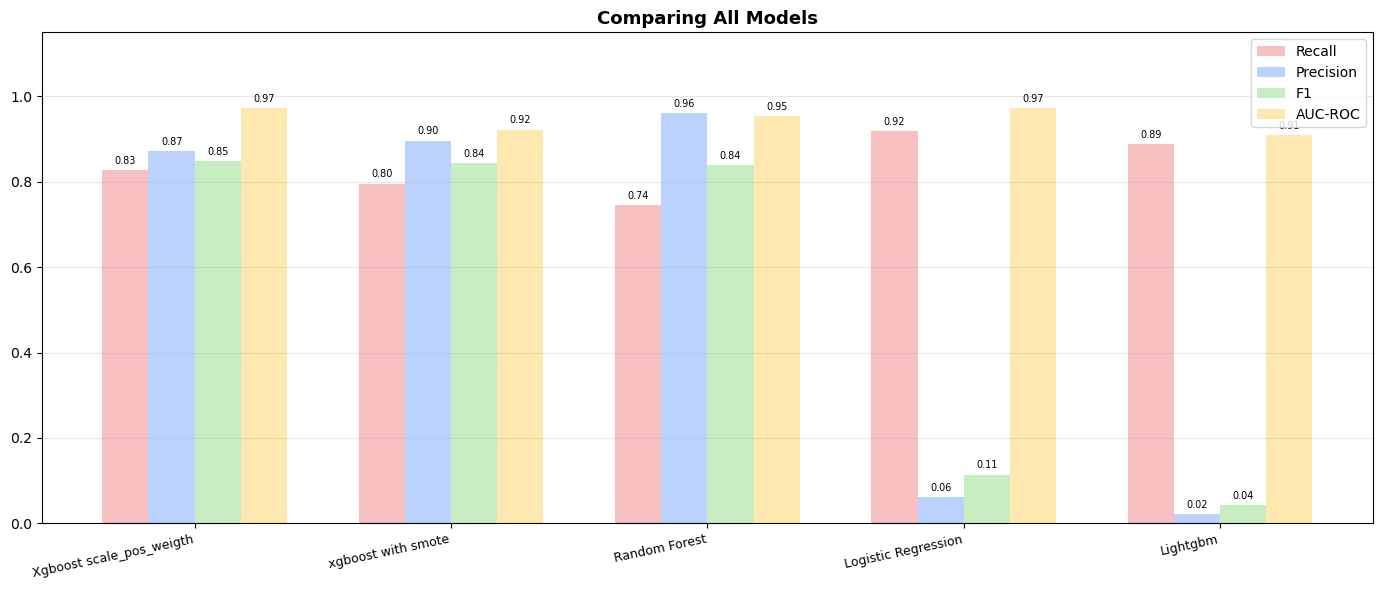

In [24]:
result_df = pd.DataFrame(result_list)
result_df = result_df.sort_values('F1',ascending=False).reset_index(drop=True)

print(result_df.to_string(index=False))

best_model_name = result_df.iloc[0]['Model']
print(f"Winner (highest F1): {best_model_name}")

# Grouped Bar Chart
metrics = ['Recall','Precision','F1','AUC-ROC']
x = np.arange(len(result_df))
width = 0.18
colors = ['#F6B6B8', '#AFCBFF', '#BDECB6', '#FFE4A3']

fig, ax = plt.subplots(figsize=(14,6))
for i, (metric,color) in enumerate(zip(metrics,colors)):
    bars = ax.bar(x + i * width, result_df[metric],width, label=metric,
                 color = color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
               f'{bar.get_height():.2f}',
               ha='center',va='bottom',fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(result_df['Model'],rotation=12,ha='right',fontsize=9)
ax.set_ylim(0,1.15)
ax.set_title('Comparing All Models',fontsize=13,fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y',alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Confusion Matrix of Best Mode


Best model selected : Xgboost scale_pos_weigth

True Positives  (Fraud caught)   : 81  ← WANT HIGH
False Negatives (Fraud missed)   : 17  ← WANT LOW
False Positives (False alarms)   : 12
True Negatives  (Legit passed)   : 56852

Fraud catch rate : 82.65%


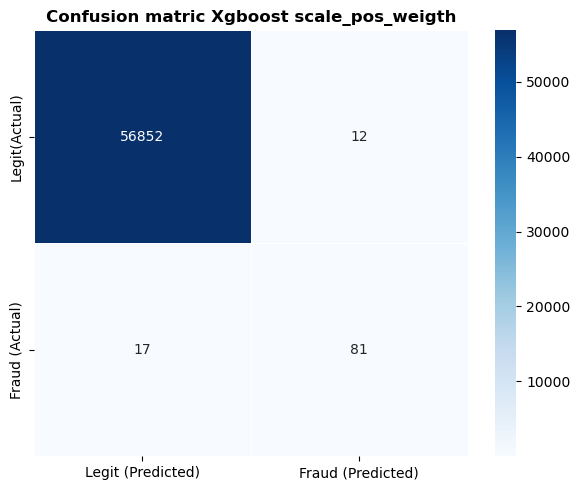

In [25]:
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test,y_pred_best)
tn,fp,fn,tp = cm.ravel()

print(f"\nBest model selected : {best_model_name}")
print(f"\nTrue Positives  (Fraud caught)   : {tp}  ← WANT HIGH")
print(f"False Negatives (Fraud missed)   : {fn}  ← WANT LOW")
print(f"False Positives (False alarms)   : {fp}")
print(f"True Negatives  (Legit passed)   : {tn}")
print(f"\nFraud catch rate : {round(tp/(tp+fn)*100, 2)}%")

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Legit (Predicted)','Fraud (Predicted)'],
            yticklabels=['Legit(Actual)','Fraud (Actual)'],
            linewidth=0.5)
plt.title(f"Confusion matric {best_model_name}",
         fontsize=12,fontweight='bold')
plt.tight_layout()

plt.savefig(
    "images/best_model_confusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

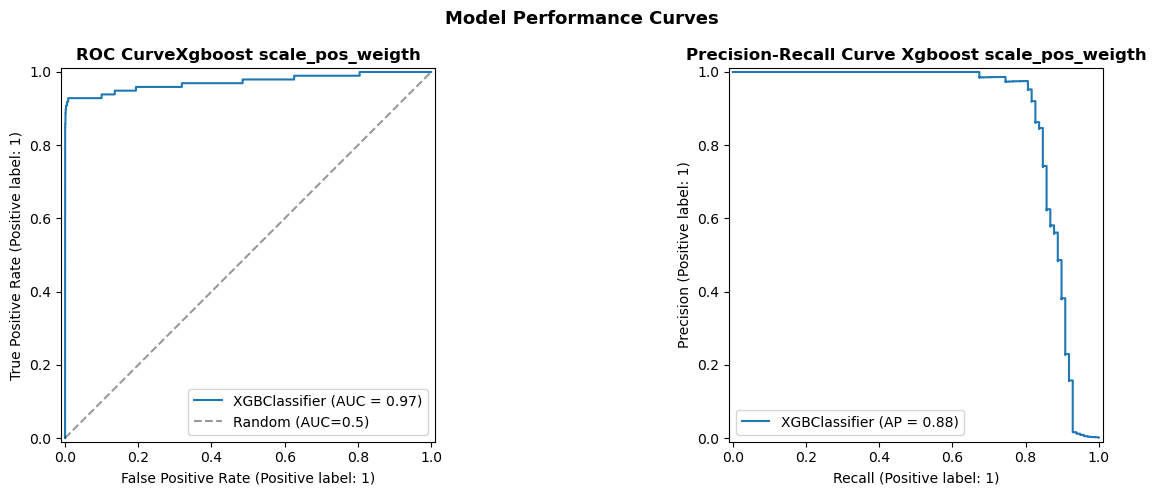

AUC-ROC Score: 0.9726


<Figure size 640x480 with 0 Axes>

In [26]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[0])
axes[0].plot([0,1], [0,1], 'k--', alpha=0.4, label='Random (AUC=0.5)')
axes[0].set_title(f"ROC Curve{best_model_name}",fontweight='bold')
axes[0].legend()

PrecisionRecallDisplay.from_estimator(best_model,X_test,y_test,ax=axes[1])
axes[1].set_title(f'Precision-Recall Curve {best_model_name}',fontweight='bold')

plt.suptitle("Model Performance Curves",fontsize=13,fontweight='bold')
plt.tight_layout()
plt.show()

y_prob_best = best_model.predict_proba(X_test)[:,1]
print(f"AUC-ROC Score: {round(roc_auc_score(y_test,y_prob_best),4)}")

plt.savefig(
    "images/model_performance_curves.png",
    dpi=300,
    bbox_inches="tight"
)


Hyperparameter Tuning

In [27]:
param_grid = {
    'max_depth' :[3,5,7],
    'learning_rate': [0.01,0.1,0.2],
    'n_estimators' :[100,200],
}


best_f1 = 0
best_params = {}
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
total = (len(param_grid['max_depth']) * 
        len(param_grid['learning_rate']) *
        len(param_grid['n_estimators']))

count = 0
print(f" {total} parameter combinations with 5 fold CV....")

for depth in param_grid['max_depth']:
    for lr in param_grid['learning_rate']:
        for n_est in param_grid['n_estimators']:
            count +=1
            model = XGBClassifier(
                max_depth = depth,
                learning_rate = lr,
                n_estimators = n_est,
                scale_pos_weight = scale_pos_weight,
                random_state=42,
                eval_metric = 'logloss'
            )
            scores = cross_val_score(model,X_train,y_train,
                                    cv=cv, scoring='f1',n_jobs=-1)
            mean_f1 = scores.mean()

            print(f"[{count:02d}/{total}] depth={depth},"
                 f"lr={lr}, n_est={n_est} -> F1={round(mean_f1,4)}")

            if mean_f1 > best_f1:
                best_f1  = mean_f1
                best_params = {
                    'max_depth' : depth,
                    'learning_rate': lr,
                    'n_estimators': n_est
                }

print(f"\nBest Parameters : {best_params}")
print(f"Best CV F1 Score: {round(best_f1, 4)}")

 18 parameter combinations with 5 fold CV....
[01/18] depth=3,lr=0.01, n_est=100 -> F1=0.1347
[02/18] depth=3,lr=0.01, n_est=200 -> F1=0.1606
[03/18] depth=3,lr=0.1, n_est=100 -> F1=0.3464
[04/18] depth=3,lr=0.1, n_est=200 -> F1=0.5988
[05/18] depth=3,lr=0.2, n_est=100 -> F1=0.6069
[06/18] depth=3,lr=0.2, n_est=200 -> F1=0.8127
[07/18] depth=5,lr=0.01, n_est=100 -> F1=0.2867
[08/18] depth=5,lr=0.01, n_est=200 -> F1=0.3466
[09/18] depth=5,lr=0.1, n_est=100 -> F1=0.7271
[10/18] depth=5,lr=0.1, n_est=200 -> F1=0.8427
[11/18] depth=5,lr=0.2, n_est=100 -> F1=0.8537
[12/18] depth=5,lr=0.2, n_est=200 -> F1=0.8611
[13/18] depth=7,lr=0.01, n_est=100 -> F1=0.4189
[14/18] depth=7,lr=0.01, n_est=200 -> F1=0.5246
[15/18] depth=7,lr=0.1, n_est=100 -> F1=0.8352
[16/18] depth=7,lr=0.1, n_est=200 -> F1=0.8534
[17/18] depth=7,lr=0.2, n_est=100 -> F1=0.8549
[18/18] depth=7,lr=0.2, n_est=200 -> F1=0.8557

Best Parameters : {'max_depth': 5, 'learning_rate': 0.2, 'n_estimators': 200}
Best CV F1 Score: 0.861

Training Final Tuned Model

In [28]:
final_model = XGBClassifier(
    **best_params,
    scale_pos_weight = scale_pos_weight,
    random_state = 42,
    eval_metric = 'logloss',
    
)
final_model.fit(X_train,y_train)
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:,1]

print("\nFinal Model — Classification Report:")
print(classification_report(y_test, y_pred_final,
                             target_names=['Legit', 'Fraud']))
print(f"Final Recall  : {round(recall_score(y_test, y_pred_final), 4)}")
print(f"Final F1      : {round(f1_score(y_test, y_pred_final), 4)}")
print(f"Final AUC-ROC : {round(roc_auc_score(y_test, y_prob_final), 4)}")


Final Model — Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Final Recall  : 0.8469
Final F1      : 0.8646
Final AUC-ROC : 0.9755


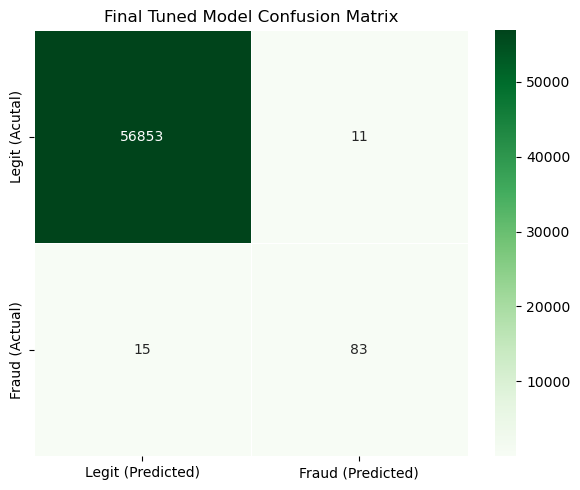

In [29]:
cm_final = confusion_matrix(y_test,y_pred_final)
tn2,fp2,fn2,tp2 = cm_final.ravel()

plt.figure(figsize=(6,5))
sns.heatmap(cm_final,annot=True, fmt='d',cmap='Greens',
           xticklabels=['Legit (Predicted)', 'Fraud (Predicted)'],
           yticklabels=['Legit (Acutal)','Fraud (Actual)'],
           linewidth = 0.5)
plt.title('Final Tuned Model Confusion Matrix')
plt.tight_layout()

plt.savefig(
    "images/final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Explaining Using SHAP


Calculating SHAP values (may take 1-2 minutes)...
SHAP values calculated.

Plot 1: Global Feature Importance (Bar)


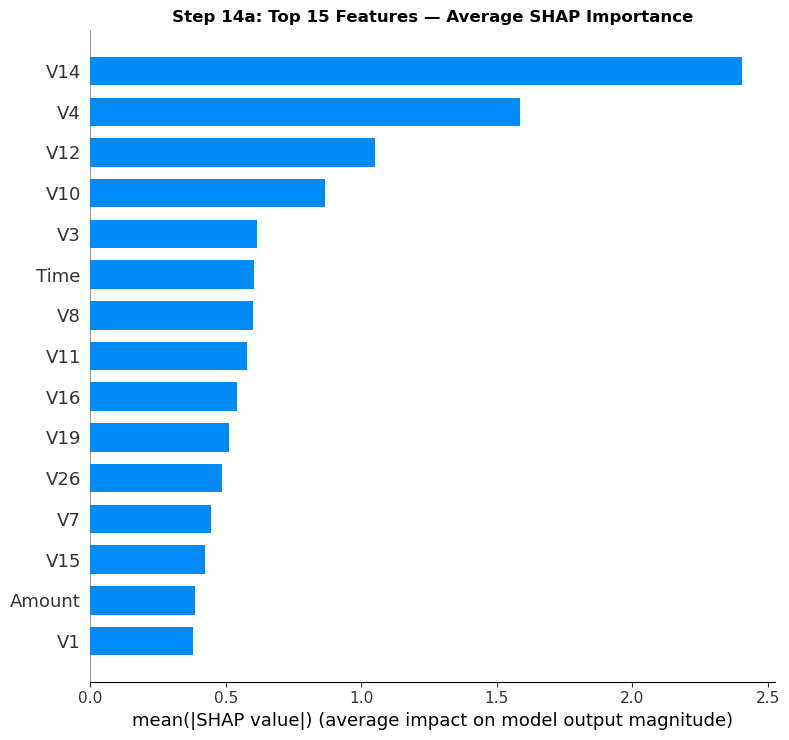


Plot 2: Feature Impact Direction (Beeswarm)


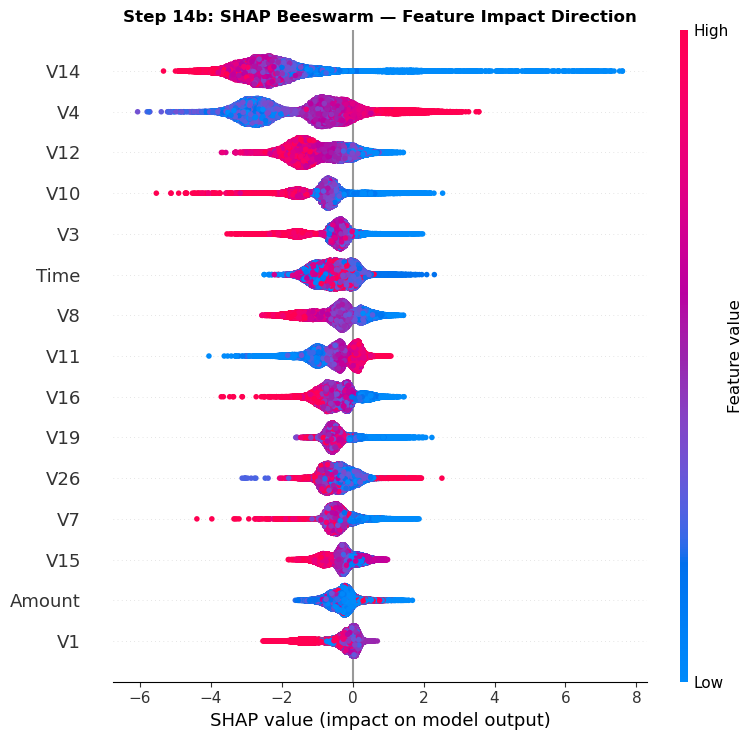


Plot 3: Explaining ONE Fraud Transaction (Waterfall)
Explaining test row 840 — actual label: FRAUD


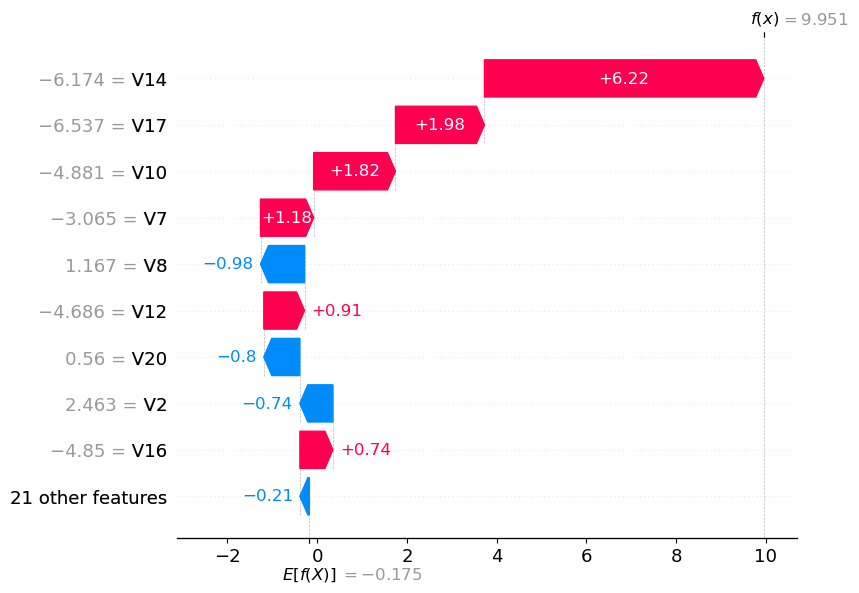

<Figure size 640x480 with 0 Axes>

In [30]:
import shap

print("\nCalculating SHAP values (may take 1-2 minutes)...")
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
print("SHAP values calculated.")
 
# Plot 1: Bar summary — global feature importance
print("\nPlot 1: Global Feature Importance (Bar)")
plt.figure()
shap.summary_plot(shap_values, X_test,
                  plot_type='bar', max_display=15, show=False)
plt.savefig(
    "images/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)
plt.title('Step 14a: Top 15 Features — Average SHAP Importance',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Plot 2: Beeswarm — direction of impact
print("\nPlot 2: Feature Impact Direction (Beeswarm)")
plt.figure()
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.savefig(
    "images/shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)
plt.title('Step 14b: SHAP Beeswarm — Feature Impact Direction',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Plot 3: Waterfall — explain one fraud transaction
print("\nPlot 3: Explaining ONE Fraud Transaction (Waterfall)")
fraud_indices = np.where(y_test.values == 1)[0]
fraud_idx     = fraud_indices[0]
 
print(f"Explaining test row {fraud_idx} — actual label: FRAUD")
shap.waterfall_plot(
    shap.Explanation(
        values      = shap_values[fraud_idx],
        base_values = explainer.expected_value,
        data        = X_test.iloc[fraud_idx],
        feature_names = X_test.columns.tolist()
    )
)
plt.savefig(
    "images/shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

12. Generative AI Fraud Investigation Report

Prompt Building

In [31]:
# ==========================================
# Step 15: Prepare Data for AI Report
# ==========================================

# Prediction for the selected fraud transaction
prediction = int(final_model.predict(X_test.iloc[[fraud_idx]])[0])

# Fraud probability
probability = float(
    final_model.predict_proba(X_test.iloc[[fraud_idx]])[0][1]
)

# SHAP values for this transaction
transaction_shap = shap_values[fraud_idx]

# Top 5 contributing features
import numpy as np
import pandas as pd

top_indices = np.argsort(np.abs(transaction_shap))[::-1][:5]

top_features = pd.DataFrame({
    "Feature": X_test.columns[top_indices],
    "Value": X_test.iloc[fraud_idx, top_indices].values,
    "SHAP Impact": transaction_shap[top_indices]
})

print(top_features)

  Feature     Value  SHAP Impact
0     V14 -6.174288     6.223867
1     V17 -6.536521     1.982613
2     V10 -4.881143     1.822614
3      V7 -3.065234     1.184536
4      V8  1.166927    -0.981029


In [32]:
prompt = f"""
You are a Senior Fraud Analyst at a global financial institution.

A machine learning model has analyzed a credit card transaction.

Prediction:
{"Fraud" if prediction == 1 else "Legitimate"}

Fraud Probability:
{probability:.2%}

Top SHAP Features:

{top_features.to_string(index=False)}

Write a professional Fraud Investigation Report.

The report should contain:

1. Executive Summary

2. Risk Level

3. Key Risk Indicators

4. SHAP Interpretation

5. Business Impact

6. Recommended Actions

Keep the report concise, factual, and professional.
Do not invent facts beyond the supplied prediction and SHAP information.
"""

In [33]:
# Import library
from groq import Groq

# Initialize the client
client = Groq(
    api_key="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"   # Replace with your actual API key
)

# Your prompt
prompt = "Explain why this transaction was predicted as fraudulent."

# Call the LLM
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {
            "role": "system",
            "content": "You are a senior fraud analyst."
        },
        {
            "role": "user",
            "content": prompt
        }
    ],
    temperature=0.3,
    max_tokens=1000,
)

# Extract and print the response
report = response.choices[0].message.content

print(report)

The transaction in question was predicted as fraudulent due to a combination of factors that raised red flags in our system. Here are the key reasons:

1. **Unusual Location**: The transaction was initiated from a location that is not consistent with the customer's usual behavior. Our data shows that the customer typically logs in from a specific IP address or geographic location, but this transaction was initiated from a different country or region.
2. **High-Risk Merchant**: The merchant involved in the transaction is classified as high-risk due to its history of fraudulent activity or association with suspicious transactions. Our system has flagged this merchant as potentially problematic, and transactions with them are subject to additional scrutiny.
3. **Large Transaction Amount**: The transaction amount is significantly higher than the customer's typical spending pattern. Our system has identified the customer's average transaction value, and this transaction exceeds that amount 

In [34]:
import os
import joblib

# Create models folder
os.makedirs("models", exist_ok=True)

# Save final model
joblib.dump(final_model, "D:/CreditCardFraud/models/xgboost.pkl")

# Save scaler
joblib.dump(scaler, "D:/CreditCardFraud/models/scaler.pkl")

print("✅ Model saved to models/xgboost.pkl")
print("✅ Scaler saved to models/scaler.pkl")

✅ Model saved to models/xgboost.pkl
✅ Scaler saved to models/scaler.pkl


In [36]:
import os
import joblib

# Create data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# Save test data
joblib.dump(X_test, "D:/CreditCardFraud/notebook/data/X_test.pkl")
joblib.dump(y_test, "D:/CreditCardFraud/notebook/data/y_test.pkl")

print("✅ Test data saved successfully!")

✅ Test data saved successfully!


In [37]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".png"):
            print(os.path.join(root, file))

.\images\best_model_confusion.png
.\images\class_distribution.png
.\images\distributions.png
.\images\feature_correlation.png
.\images\final_confusion_matrix.png
.\images\model_comparison.png
.\images\model_performance_curves.png
.\images\shap_bar.png
.\images\shap_beeswarm.png
.\images\shap_waterfall.png
.\images\smote_comparison.png
